<a href="https://colab.research.google.com/github/sivadharshangiri222-web/Data_Cleaning_Reporting_Automation.ipynb/blob/main/Data_Cleaning_Reporting_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Data Cleaning & Reporting Automation

## Project Overview

This project focuses on automating the data cleaning, analysis, visualization, and reporting process using Python.

The system processes a raw sales dataset and automatically identifies and handles common data quality problems such as missing values, duplicate records, inconsistent text values, and incorrect data formats.

After cleaning the dataset, the system performs automated sales analysis and generates key performance indicators (KPIs), statistical summaries, visualizations, and an Excel-based business report.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- OpenPyXL
- Google Colab
- Microsoft Excel

### Project Objective

The main objective is to reduce manual effort in data preprocessing and reporting by creating an automated workflow that transforms raw data into a clean, analyzed, and report-ready dataset.


## 🎯 Project Objectives

1. Identify missing values in raw datasets.
2. Detect and remove duplicate records.
3. Standardize inconsistent data.
4. Convert columns into appropriate data types.
5. Automate data preprocessing using Python.
6. Calculate important business KPIs.
7. Analyze sales performance by month, category, region, and product.
8. Generate automated data visualizations.
9. Create a structured Excel report.
10. Improve reporting efficiency and reduce repetitive manual work.

## 🔄 Project Methodology

The project follows a systematic data processing pipeline:

**Raw Data → Data Quality Analysis → Data Cleaning → Data Validation → Data Analysis → Visualization → Automated Reporting**

### 1. Data Collection
A sales dataset is loaded into the Python environment.

### 2. Data Quality Analysis
The dataset is examined for missing values, duplicate records, data types, and unique values.

### 3. Data Cleaning
Missing values are handled, duplicate records are removed, and inconsistent text values are standardized.

### 4. Data Transformation
Dates and numerical columns are converted into appropriate formats.

### 5. Data Analysis
Business KPIs and summary statistics are calculated.

### 6. Visualization
Charts are generated to identify trends and compare business performance.

### 7. Automated Reporting
The cleaned data and analytical results are exported into a structured Excel report.

In [1]:
# ============================================
# DATA CLEANING & REPORTING AUTOMATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# CREATE SAMPLE RAW SALES DATA
# ============================================

np.random.seed(42)

products = [
    "Laptop", "Smartphone", "Tablet",
    "Headphones", "Keyboard", "Mouse",
    "Monitor", "Printer"
]

categories = [
    "Electronics", "electronics", " ELECTRONICS ",
    "Accessories", "accessories"
]

regions = [
    "Chennai", "chennai", " CHENNAI ",
    "Bangalore", "bangalore",
    "Mumbai", "mumbai"
]

payment_methods = [
    "UPI", "upi", "Credit Card",
    "credit card", "Cash", "cash"
]

data = []

for i in range(1, 1001):

    product = np.random.choice(products)
    category = np.random.choice(categories)
    region = np.random.choice(regions)

    quantity = np.random.randint(1, 10)
    unit_price = np.random.randint(500, 80000)

    discount = np.random.choice(
        [0, 5, 10, 15, np.nan]
    )

    sales = quantity * unit_price

    payment = np.random.choice(payment_methods)

    date = pd.Timestamp("2025-01-01") + pd.to_timedelta(
        np.random.randint(0, 365), unit="D"
    )

    data.append([
        f"ORD{i:04d}",
        date,
        f"Customer_{np.random.randint(1, 301)}",
        product,
        category,
        region,
        quantity,
        unit_price,
        discount,
        sales,
        payment
    ])

columns = [
    "Order_ID",
    "Order_Date",
    "Customer_Name",
    "Product",
    "Category",
    "Region",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Payment_Method"
]

df = pd.DataFrame(data, columns=columns)

# Add missing values
df.loc[np.random.choice(df.index, 30, replace=False), "Customer_Name"] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), "Region"] = np.nan
df.loc[np.random.choice(df.index, 15, replace=False), "Quantity"] = np.nan

# Add duplicate records
duplicates = df.sample(20, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

# Save raw dataset
os.makedirs("data", exist_ok=True)

df.to_excel(
    "data/raw_sales_data.xlsx",
    index=False
)

print("Raw dataset created successfully!")
print(f"Total records: {len(df)}")

Raw dataset created successfully!
Total records: 1020


In [3]:
# Display first 10 rows

df.head(10)

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Payment_Method
0,ORD0001,2025-08-03,Customer_88,Monitor,Accessories,bangalore,8.0,77320,5.0,618560,Credit Card
1,ORD0002,2025-10-21,Customer_192,Keyboard,Accessories,CHENNAI,6.0,65320,5.0,391920,credit card
2,ORD0003,2025-02-18,Customer_59,Headphones,accessories,Chennai,6.0,72432,15.0,434592,UPI
3,ORD0004,2025-05-11,Customer_135,Monitor,electronics,Bangalore,3.0,67935,15.0,203805,UPI
4,ORD0005,2025-01-14,Customer_242,Keyboard,Electronics,mumbai,2.0,11127,0.0,22254,credit card
5,ORD0006,2025-09-21,Customer_35,Smartphone,Electronics,chennai,5.0,23983,15.0,119915,Cash
6,ORD0007,2025-02-23,Customer_106,Mouse,Electronics,Bangalore,2.0,69979,15.0,139958,upi
7,ORD0008,2025-07-21,Customer_270,Headphones,accessories,mumbai,2.0,72909,15.0,145818,upi
8,ORD0009,2025-02-22,Customer_280,Monitor,Accessories,Chennai,8.0,23747,NaN,189976,upi
9,ORD0010,2025-12-11,Customer_9,Smartphone,Electronics,Bangalore,9.0,38544,NaN,346896,UPI


In [4]:
# Dataset information

print("Dataset Shape:", df.shape)

print("\nColumn Information:")
df.info()

Dataset Shape: (1020, 11)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1020 non-null   object        
 1   Order_Date      1020 non-null   datetime64[ns]
 2   Customer_Name   990 non-null    object        
 3   Product         1020 non-null   object        
 4   Category        1020 non-null   object        
 5   Region          1000 non-null   object        
 6   Quantity        1005 non-null   float64       
 7   Unit_Price      1020 non-null   int64         
 8   Discount        816 non-null    float64       
 9   Sales           1020 non-null   int64         
 10  Payment_Method  1020 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 87.8+ KB


In [5]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID            0
Order_Date          0
Customer_Name      30
Product             0
Category            0
Region             20
Quantity           15
Unit_Price          0
Discount          204
Sales               0
Payment_Method      0
dtype: int64


In [6]:
# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 20


In [7]:
# ============================================
# DATA QUALITY ANALYSIS
# ============================================

quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isnull().sum().values,
    "Missing_Percentage": (
        df.isnull().mean().values * 100
    ).round(2),
    "Unique_Values": [
        df[col].nunique()
        for col in df.columns
    ]
})

print("DATA QUALITY REPORT")
print("=" * 60)

display(quality_report)

DATA QUALITY REPORT


,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
0,Order_ID,object,0,0.00,1000
1,Order_Date,datetime64[ns],0,0.00,344
2,Customer_Name,object,30,2.94,286
3,Product,object,0,0.00,8
4,Category,object,0,0.00,5
5,Region,object,20,1.96,7
6,Quantity,float64,15,1.47,9
7,Unit_Price,int64,0,0.00,997
8,Discount,float64,204,20.00,4
9,Sales,int64,0,0.00,999


In [8]:
# ============================================
# AUTOMATED DATA CLEANING
# ============================================

def clean_data(data):

    cleaned = data.copy()

    # ----------------------------------------
    # 1. Remove duplicate records
    # ----------------------------------------
    before_duplicates = len(cleaned)

    cleaned = cleaned.drop_duplicates()

    duplicates_removed = (
        before_duplicates - len(cleaned)
    )

    # ----------------------------------------
    # 2. Clean column names
    # ----------------------------------------
    cleaned.columns = (
        cleaned.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    # ----------------------------------------
    # 3. Clean text columns
    # ----------------------------------------
    text_columns = [
        "Customer_Name",
        "Product",
        "Category",
        "Region",
        "Payment_Method"
    ]

    for column in text_columns:

        cleaned[column] = (
            cleaned[column]
            .astype("string")
            .str.strip()
            .str.title()
        )

    # ----------------------------------------
    # 4. Handle missing categorical values
    # ----------------------------------------
    categorical_columns = [
        "Customer_Name",
        "Region",
        "Payment_Method"
    ]

    for column in categorical_columns:

        cleaned[column] = cleaned[column].fillna(
            "Unknown"
        )

    # ----------------------------------------
    # 5. Handle missing numerical values
    # ----------------------------------------
    cleaned["Quantity"] = cleaned["Quantity"].fillna(
        cleaned["Quantity"].median()
    )

    cleaned["Discount"] = cleaned["Discount"].fillna(0)

    # ----------------------------------------
    # 6. Convert data types
    # ----------------------------------------
    cleaned["Order_Date"] = pd.to_datetime(
        cleaned["Order_Date"],
        errors="coerce"
    )

    cleaned["Quantity"] = pd.to_numeric(
        cleaned["Quantity"],
        errors="coerce"
    )

    cleaned["Unit_Price"] = pd.to_numeric(
        cleaned["Unit_Price"],
        errors="coerce"
    )

    cleaned["Sales"] = pd.to_numeric(
        cleaned["Sales"],
        errors="coerce"
    )

    # ----------------------------------------
    # 7. Recalculate Sales
    # ----------------------------------------
    cleaned["Sales"] = (
        cleaned["Quantity"] *
        cleaned["Unit_Price"]
    )

    # ----------------------------------------
    # 8. Sort by date
    # ----------------------------------------
    cleaned = cleaned.sort_values(
        "Order_Date"
    )

    # ----------------------------------------
    # 9. Reset index
    # ----------------------------------------
    cleaned = cleaned.reset_index(drop=True)

    return cleaned, duplicates_removed

In [9]:
# ============================================
# RUN AUTOMATED CLEANING
# ============================================

cleaned_df, duplicates_removed = clean_data(df)

print("DATA CLEANING COMPLETED")
print("=" * 50)

print("Original Records :", len(df))
print("Cleaned Records  :", len(cleaned_df))
print("Duplicates Removed:", duplicates_removed)

DATA CLEANING COMPLETED
Original Records : 1020
Cleaned Records  : 1000
Duplicates Removed: 20


In [10]:
# ============================================
# CLEANED DATA PREVIEW
# ============================================

display(cleaned_df.head(10))

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Payment_Method
0,ORD0221,2025-01-01,Customer_147,Smartphone,Electronics,Bangalore,8.0,37708,15.0,301664.0,Upi
1,ORD0666,2025-01-01,Customer_266,Monitor,Electronics,Chennai,6.0,44939,0.0,269634.0,Cash
2,ORD0878,2025-01-02,Customer_243,Printer,Electronics,Chennai,3.0,11610,5.0,34830.0,Credit Card
3,ORD0877,2025-01-02,Customer_244,Laptop,Accessories,Mumbai,5.0,39890,0.0,199450.0,Cash
4,ORD0407,2025-01-03,Customer_28,Keyboard,Accessories,Bangalore,2.0,18635,15.0,37270.0,Upi
5,ORD0249,2025-01-03,Customer_144,Smartphone,Electronics,Mumbai,1.0,46979,15.0,46979.0,Credit Card
6,ORD0052,2025-01-04,Customer_16,Smartphone,Accessories,Mumbai,3.0,10323,0.0,30969.0,Cash
7,ORD0648,2025-01-04,Customer_132,Tablet,Accessories,Chennai,1.0,6367,0.0,6367.0,Credit Card
8,ORD0823,2025-01-04,Customer_167,Monitor,Electronics,Chennai,2.0,52088,15.0,104176.0,Cash
9,ORD0014,2025-01-05,Customer_218,Tablet,Electronics,Chennai,3.0,8610,10.0,25830.0,Upi


In [11]:
# ============================================
# CHECK REMAINING MISSING VALUES
# ============================================

print("Remaining Missing Values:")
print(cleaned_df.isnull().sum())

Remaining Missing Values:
Order_ID          0
Order_Date        0
Customer_Name     0
Product           0
Category          0
Region            0
Quantity          0
Unit_Price        0
Discount          0
Sales             0
Payment_Method    0
dtype: int64


In [12]:
# ============================================
# BEFORE vs AFTER
# ============================================

comparison = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Missing Values",
        "Duplicate Records"
    ],

    "Before Cleaning": [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],

    "After Cleaning": [
        len(cleaned_df),
        cleaned_df.isnull().sum().sum(),
        cleaned_df.duplicated().sum()
    ]
})

display(comparison)

,Metric,Before Cleaning,After Cleaning
0,Total Records,1020,1000
1,Missing Values,269,0
2,Duplicate Records,20,0


In [13]:
# ============================================
# SAVE CLEANED DATA
# ============================================

os.makedirs("output", exist_ok=True)

cleaned_df.to_excel(
    "output/cleaned_sales_data.xlsx",
    index=False
)

print("✓ Cleaned dataset saved successfully!")

✓ Cleaned dataset saved successfully!


In [14]:
# ============================================
# AUTOMATED KPI ANALYSIS
# ============================================

total_sales = cleaned_df["Sales"].sum()
total_orders = cleaned_df["Order_ID"].nunique()
average_order_value = total_sales / total_orders
total_quantity = cleaned_df["Quantity"].sum()
total_customers = cleaned_df["Customer_Name"].nunique()

top_product = (
    cleaned_df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

top_category = (
    cleaned_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

top_region = (
    cleaned_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

print("AUTOMATED BUSINESS REPORT")
print("=" * 50)

print(f"Total Sales       : ₹{total_sales:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Average Order     : ₹{average_order_value:,.2f}")
print(f"Total Quantity    : {total_quantity:,.0f}")
print(f"Total Customers   : {total_customers:,}")
print(f"Top Product       : {top_product}")
print(f"Top Category      : {top_category}")
print(f"Top Region        : {top_region}")

AUTOMATED BUSINESS REPORT
Total Sales       : ₹193,600,128.00
Total Orders      : 1,000
Average Order     : ₹193,600.13
Total Quantity    : 4,968
Total Customers   : 287
Top Product       : Tablet
Top Category      : Electronics
Top Region        : Chennai


In [15]:
# ============================================
# MONTHLY SALES ANALYSIS
# ============================================

cleaned_df["Month"] = cleaned_df["Order_Date"].dt.to_period("M")

monthly_sales = (
    cleaned_df.groupby("Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

display(monthly_sales)

,Month,Sales
0,2025-01,10624989.0
1,2025-02,13100067.0
2,2025-03,19832389.0
3,2025-04,16400181.0
4,2025-05,14119693.0
5,2025-06,16794536.0
6,2025-07,19908047.0
7,2025-08,17694821.0
8,2025-09,14540716.0
9,2025-10,18330880.0


In [16]:
# ============================================
# CATEGORY SALES ANALYSIS
# ============================================

category_sales = (
    cleaned_df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(category_sales)

,Category,Sales
0,Electronics,116665320.0
1,Accessories,76934808.0


In [17]:
# ============================================
# REGIONAL SALES ANALYSIS
# ============================================

regional_sales = (
    cleaned_df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(regional_sales)

,Region,Sales
0,Chennai,81913838.0
1,Bangalore,59653265.0
2,Mumbai,47184187.0
3,Unknown,4848838.0


In [18]:
# ============================================
# PRODUCT SALES ANALYSIS
# ============================================

product_sales = (
    cleaned_df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(product_sales)

,Product,Sales
0,Tablet,27188405.0
1,Laptop,26662537.0
2,Monitor,26299679.0
3,Smartphone,24172841.0
4,Keyboard,23714454.0
5,Printer,23591587.0
6,Mouse,23200472.0
7,Headphones,18770153.0


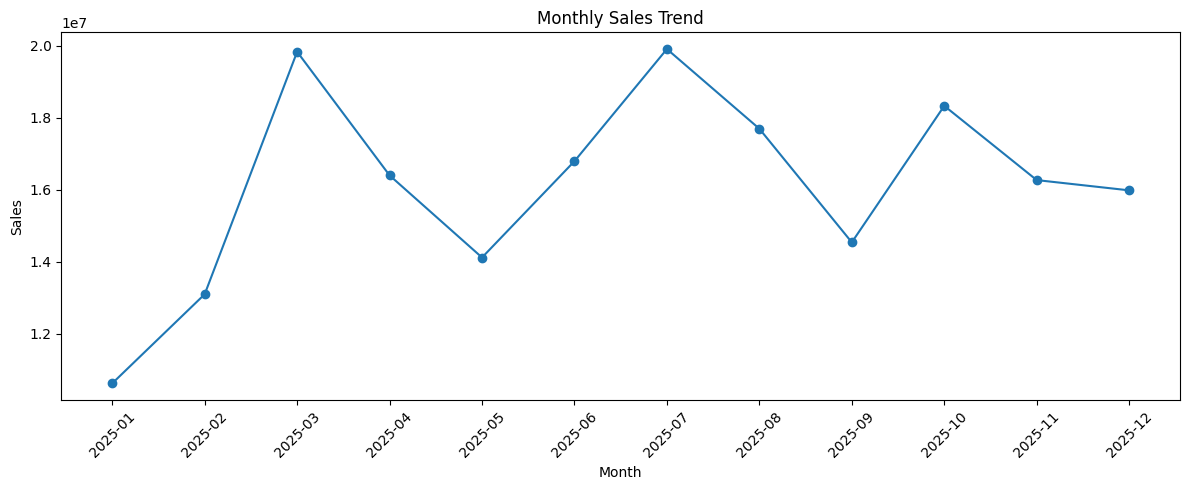

In [19]:
# ============================================
# MONTHLY SALES CHART
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

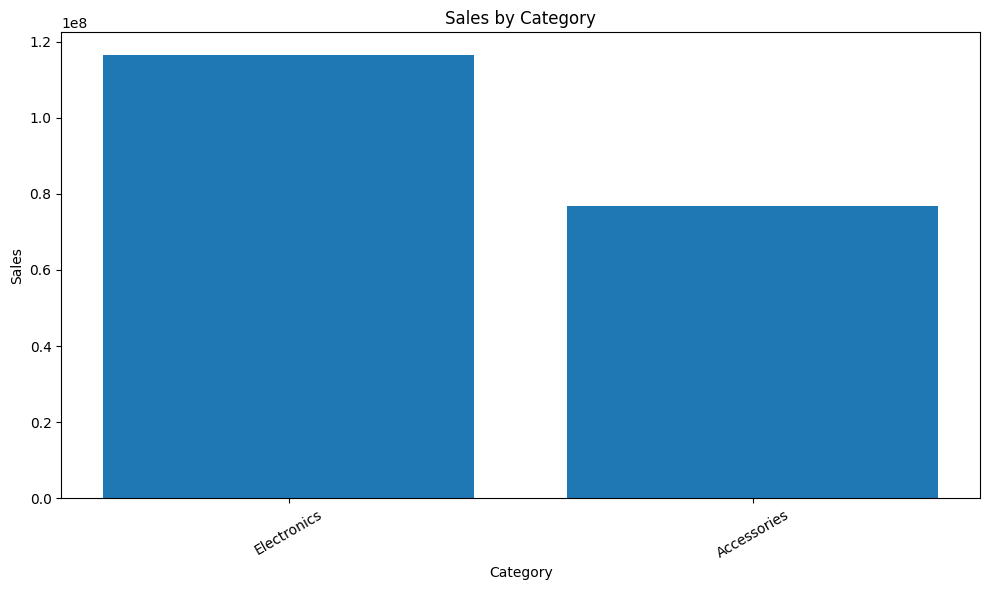

In [20]:
# ============================================
# CATEGORY SALES CHART
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

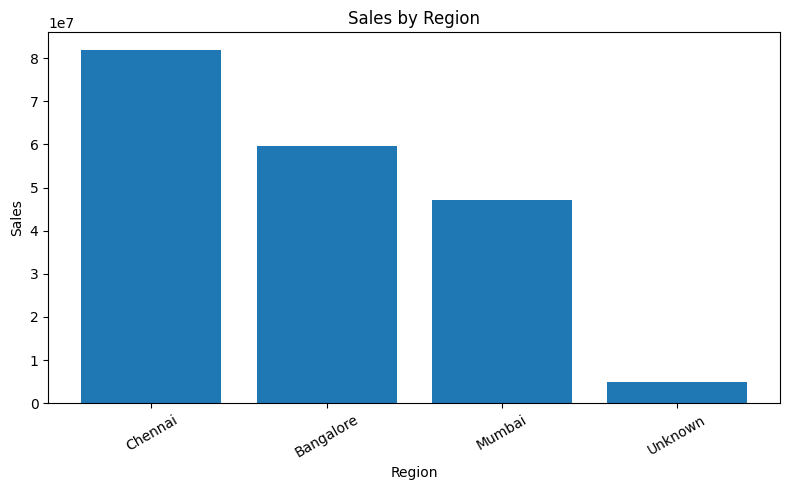

In [21]:
# ============================================
# REGIONAL SALES CHART
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    regional_sales["Region"],
    regional_sales["Sales"]
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    "regional_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

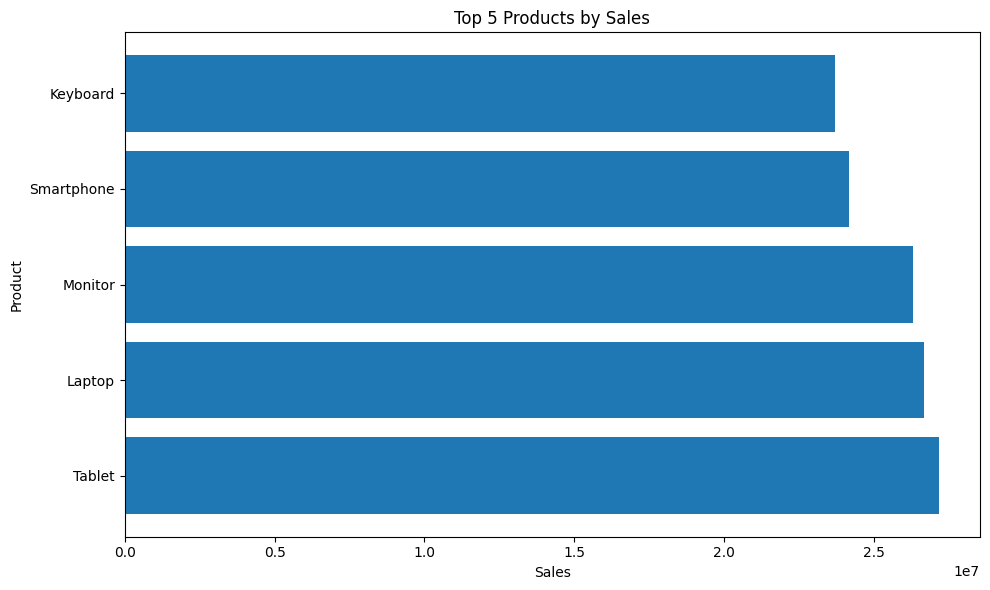

In [22]:
# ============================================
# TOP PRODUCTS CHART
# ============================================

top_products = product_sales.head(5)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Product"],
    top_products["Sales"]
)

plt.title("Top 5 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "top_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# ============================================
# DATA QUALITY SCORE
# ============================================

total_cells = df.shape[0] * df.shape[1]

missing_cells = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

quality_score = (
    1 -
    (
        missing_cells +
        duplicate_rows
    ) / total_cells
) * 100

quality_score = max(0, min(100, quality_score))

print(f"Data Quality Score: {quality_score:.2f}%")

Data Quality Score: 97.42%


In [24]:
# ============================================
# AUTOMATED EXCEL REPORT
# ============================================

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.chart import BarChart, LineChart, Reference

report_path = "output/Automated_Sales_Report.xlsx"

with pd.ExcelWriter(
    report_path,
    engine="openpyxl"
) as writer:

    # Dashboard
    dashboard = pd.DataFrame({
        "Metric": [
            "Total Sales",
            "Total Orders",
            "Average Order Value",
            "Total Quantity",
            "Total Customers",
            "Top Product",
            "Top Category",
            "Top Region",
            "Data Quality Score"
        ],

        "Value": [
            total_sales,
            total_orders,
            average_order_value,
            total_quantity,
            total_customers,
            top_product,
            top_category,
            top_region,
            quality_score
        ]
    })

    dashboard.to_excel(
        writer,
        sheet_name="Dashboard",
        index=False
    )

    # Cleaned data
    cleaned_df.to_excel(
        writer,
        sheet_name="Cleaned_Data",
        index=False
    )

    # Data quality
    quality_report.to_excel(
        writer,
        sheet_name="Data_Quality",
        index=False
    )

    # Monthly analysis
    monthly_sales.to_excel(
        writer,
        sheet_name="Monthly_Sales",
        index=False
    )

    # Category analysis
    category_sales.to_excel(
        writer,
        sheet_name="Category_Sales",
        index=False
    )

    # Regional analysis
    regional_sales.to_excel(
        writer,
        sheet_name="Regional_Sales",
        index=False
    )

    # Product analysis
    product_sales.to_excel(
        writer,
        sheet_name="Product_Sales",
        index=False
    )

print("✓ Automated Excel report created!")
print(f"Report location: {report_path}")

✓ Automated Excel report created!
Report location: output/Automated_Sales_Report.xlsx


In [25]:
# ============================================
# FORMAT EXCEL REPORT
# ============================================

wb = load_workbook(report_path)

for ws in wb.worksheets:

    # Header formatting
    for cell in ws[1]:

        cell.font = Font(
            bold=True
        )

        cell.alignment = Alignment(
            horizontal="center"
        )

    # Adjust column widths
    for column in ws.columns:

        max_length = 0
        column_letter = column[0].column_letter

        for cell in column:

            if cell.value is not None:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        ws.column_dimensions[
            column_letter
        ].width = min(
            max_length + 2,
            30
        )

wb.save(report_path)

print("✓ Excel report formatted successfully!")

✓ Excel report formatted successfully!


In [26]:
# ============================================
# DOWNLOAD FINAL REPORT
# ============================================

from google.colab import files

files.download(
    "output/Automated_Sales_Report.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# ============================================
# AUTOMATED PROJECT SUMMARY
# ============================================

print("=" * 70)
print("           AUTOMATED SALES REPORT SUMMARY")
print("=" * 70)

print(f"""
Dataset Summary
---------------
Original Records       : {len(df):,}
Cleaned Records        : {len(cleaned_df):,}
Duplicates Removed     : {duplicates_removed:,}
Remaining Missing Data : {cleaned_df.isnull().sum().sum():,}

Business Performance
--------------------
Total Sales            : ₹{total_sales:,.2f}
Total Orders           : {total_orders:,}
Average Order Value    : ₹{average_order_value:,.2f}
Total Quantity Sold    : {total_quantity:,.0f}
Total Customers        : {total_customers:,}

Top Performers
--------------
Top Product            : {top_product}
Top Category           : {top_category}
Top Region             : {top_region}

Data Quality
------------
Data Quality Score     : {quality_score:.2f}%

Report Status
-------------
✓ Data cleaning completed
✓ Data analysis completed
✓ Visualizations generated
✓ Excel report generated
""")

print("=" * 70)

           AUTOMATED SALES REPORT SUMMARY

Dataset Summary
---------------
Original Records       : 1,020
Cleaned Records        : 1,000
Duplicates Removed     : 20
Remaining Missing Data : 0

Business Performance
--------------------
Total Sales            : ₹193,600,128.00
Total Orders           : 1,000
Average Order Value    : ₹193,600.13
Total Quantity Sold    : 4,968
Total Customers        : 287

Top Performers
--------------
Top Product            : Tablet
Top Category           : Electronics
Top Region             : Chennai

Data Quality
------------
Data Quality Score     : 97.42%

Report Status
-------------
✓ Data cleaning completed
✓ Data analysis completed
✓ Visualizations generated
✓ Excel report generated



# 📈 Results

The Data Cleaning & Reporting Automation system successfully processed the raw sales dataset and transformed it into a clean, structured, and analysis-ready dataset.

## Data Processing Results

- Duplicate records were automatically detected and removed.
- Missing values were identified and handled.
- Inconsistent text values were standardized.
- Numerical columns were converted into appropriate data types.
- Date values were converted into a consistent format.
- Sales values were automatically recalculated.

## Business Analysis Results

The system automatically generated important business metrics including:

- Total Sales
- Total Orders
- Average Order Value
- Total Quantity Sold
- Total Customers
- Top Product
- Top Category
- Top Region
- Monthly Sales Trends

## Visualization Results

The system generated automated visualizations for:

1. Monthly Sales Trend
2. Sales by Category
3. Sales by Region
4. Top 5 Products by Sales

## Reporting Results

The final Excel report contains:

- 📊 Dashboard
- 🧹 Cleaned Data
- 🔍 Data Quality Report
- 📈 Monthly Sales Analysis
- 📊 Category Sales Analysis
- 🌎 Regional Sales Analysis
- 🏆 Product Sales Analysis

The complete workflow is automated using Python, reducing the need for repetitive manual data-cleaning and reporting operations.

# 🏁 Conclusion

The Data Cleaning & Reporting Automation project demonstrates how Python can be used to automate the complete data preprocessing and reporting workflow.

The system successfully identifies common data quality issues such as missing values, duplicate records, and inconsistent data. It then cleans and transforms the dataset before performing automated analysis and generating meaningful visualizations.

The final Excel report provides a structured view of the cleaned data, data quality information, business KPIs, and analytical results.

This automation improves reporting efficiency, reduces repetitive manual work, and helps organizations make better use of their data.

Overall, the project demonstrates practical applications of **Python, Pandas, data preprocessing, data visualization, Excel automation, and reporting**.

# 🚀 Future Enhancements

The current system can be further improved by adding:

- Real-time data ingestion
- Power BI dashboard integration
- Automated email reporting
- Scheduled report generation
- Cloud database integration
- Interactive web dashboard
- Machine learning-based sales forecasting
- Automated anomaly detection
- Real-time data quality monitoring
- Integration with APIs and business systems

In [29]:
# ============================================
# PROFESSIONAL EXCEL DASHBOARD - FIXED
# ============================================

from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment
from openpyxl.chart import BarChart, LineChart, Reference

# Load existing report
wb = load_workbook(report_path)

# Get dashboard sheet
ws = wb["Dashboard"]

# Remove existing charts
ws._charts = []

# Clear dashboard cells
for row in ws.iter_rows():
    for cell in row:
        cell.value = None

# --------------------------------------------
# DASHBOARD TITLE
# --------------------------------------------

ws.merge_cells("A1:H2")

ws["A1"] = "AUTOMATED SALES ANALYTICS DASHBOARD"

ws["A1"].font = Font(
    size=20,
    bold=True
)

ws["A1"].alignment = Alignment(
    horizontal="center",
    vertical="center"
)

# --------------------------------------------
# SUBTITLE
# --------------------------------------------

ws.merge_cells("A3:H3")

ws["A3"] = "Data Cleaning & Reporting Automation"

ws["A3"].font = Font(
    size=12,
    italic=True
)

ws["A3"].alignment = Alignment(
    horizontal="center"
)

# --------------------------------------------
# KPI CARDS
# --------------------------------------------

kpis = [
    ("A5:B7", "TOTAL SALES", f"₹{total_sales:,.2f}"),
    ("C5:D7", "TOTAL ORDERS", f"{total_orders:,}"),
    ("E5:F7", "AVG ORDER VALUE", f"₹{average_order_value:,.2f}"),
    ("G5:H7", "DATA QUALITY", f"{quality_score:.2f}%")
]

for cell_range, title, value in kpis:

    ws.merge_cells(cell_range)

    start_cell = cell_range.split(":")[0]

    cell = ws[start_cell]

    cell.value = f"{title}\n{value}"

    cell.font = Font(
        size=14,
        bold=True
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

# --------------------------------------------
# TOP PERFORMERS
# --------------------------------------------

ws["A9"] = "TOP PRODUCT"
ws["B9"] = top_product

ws["D9"] = "TOP CATEGORY"
ws["E9"] = top_category

ws["G9"] = "TOP REGION"
ws["H9"] = top_region

for cell in ["A9", "D9", "G9"]:
    ws[cell].font = Font(bold=True)

for cell in ["B9", "E9", "H9"]:
    ws[cell].font = Font(bold=True)

# --------------------------------------------
# REPORT INFORMATION
# --------------------------------------------

ws["A11"] = "REPORT INFORMATION"

ws["A11"].font = Font(
    size=14,
    bold=True
)

ws["A12"] = "Original Records"
ws["B12"] = len(df)

ws["A13"] = "Cleaned Records"
ws["B13"] = len(cleaned_df)

ws["A14"] = "Duplicates Removed"
ws["B14"] = duplicates_removed

ws["A15"] = "Missing Values After Cleaning"
ws["B15"] = cleaned_df.isnull().sum().sum()

# --------------------------------------------
# COLUMN WIDTHS
# --------------------------------------------

widths = {
    "A": 22,
    "B": 22,
    "C": 18,
    "D": 22,
    "E": 22,
    "F": 18,
    "G": 22,
    "H": 22
}

for column, width in widths.items():
    ws.column_dimensions[column].width = width

# --------------------------------------------
# MONTHLY SALES CHART
# --------------------------------------------

monthly_ws = wb["Monthly_Sales"]

line_chart = LineChart()

line_chart.title = "Monthly Sales Trend"
line_chart.y_axis.title = "Sales"
line_chart.x_axis.title = "Month"

data = Reference(
    monthly_ws,
    min_col=2,
    min_row=1,
    max_row=monthly_ws.max_row
)

categories = Reference(
    monthly_ws,
    min_col=1,
    min_row=2,
    max_row=monthly_ws.max_row
)

line_chart.add_data(
    data,
    titles_from_data=True
)

line_chart.set_categories(categories)

line_chart.height = 8
line_chart.width = 15

ws.add_chart(
    line_chart,
    "D11"
)

# --------------------------------------------
# CATEGORY SALES CHART
# --------------------------------------------

category_ws = wb["Category_Sales"]

bar_chart = BarChart()

bar_chart.title = "Sales by Category"
bar_chart.y_axis.title = "Sales"
bar_chart.x_axis.title = "Category"

data = Reference(
    category_ws,
    min_col=2,
    min_row=1,
    max_row=category_ws.max_row
)

categories = Reference(
    category_ws,
    min_col=1,
    min_row=2,
    max_row=category_ws.max_row
)

bar_chart.add_data(
    data,
    titles_from_data=True
)

bar_chart.set_categories(categories)

bar_chart.height = 8
bar_chart.width = 15

ws.add_chart(
    bar_chart,
    "D26"
)

# --------------------------------------------
# SAVE
# --------------------------------------------

wb.save(report_path)

print("✓ Professional Excel Dashboard created successfully!")
print(f"✓ Report saved at: {report_path}")

✓ Professional Excel Dashboard created successfully!
✓ Report saved at: output/Automated_Sales_Report.xlsx


In [30]:
from google.colab import files

files.download(
    "output/Automated_Sales_Report.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>